In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../dataset/raw/cardio_train.csv", sep=";")

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df = df.drop(columns=["id"])

In [5]:
df["age_years"] = (df["age"] / 365.25).astype(int)

In [6]:
# 1. Blood Pressure Filtering (Realistic physiological range)
bp_filter = (df["ap_hi"] >= 80) & (df["ap_hi"] <= 220) & \
            (df["ap_lo"] >= 50) & (df["ap_lo"] <= 130) & \
            (df["ap_hi"] > df["ap_lo"])

# 2. Height and Weight Filtering
hw_filter = (df["height"] >= 120) & (df["height"] <= 220) & \
            (df["weight"] >= 35) & (df["weight"] <= 200)

# Apply both filters together
df_cleaned = df[bp_filter & hw_filter].copy()

print("Cleaned Dataset Shape:", df_cleaned.shape)
print("Outlier / Corrupted Rows Removed:", len(df) - len(df_cleaned))

Cleaned Dataset Shape: (68554, 13)
Outlier / Corrupted Rows Removed: 1446


In [7]:
# Formula: BMI = weight (kg) / (height (m))^2
df_cleaned["bmi"] = df_cleaned["weight"] / ((df_cleaned["height"] / 100) ** 2)
df_cleaned["bmi"] = df_cleaned["bmi"].round(2)

In [8]:
df_cleaned[["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]].describe()

,age_years,height,weight,ap_hi,ap_lo,bmi
count,68554.000000,68554.000000,68554.000000,68554.000000,68554.000000,68554.000000
mean,52.791741,164.417029,74.119236,126.647446,81.297692,27.458390
std,6.764105,7.908209,14.280824,16.596607,9.345696,5.253103
min,29.000000,120.000000,35.000000,80.000000,50.000000,12.250000
25%,48.000000,159.000000,65.000000,120.000000,80.000000,23.880000
50%,53.000000,165.000000,72.000000,120.000000,80.000000,26.350000
75%,58.000000,170.000000,82.000000,140.000000,90.000000,30.120000
max,64.000000,207.000000,200.000000,220.000000,130.000000,108.170000


In [9]:
import os
os.makedirs("../dataset/processed", exist_ok=True)

df_cleaned.to_csv("../dataset/processed/cardio_cleaned.csv", index=False)
print("Saved successfully to dataset/processed/cardio_cleaned.csv")

Saved successfully to dataset/processed/cardio_cleaned.csv


In [10]:
df.shape

(70000, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
 12  age_years    70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [12]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,52.803257
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.762462
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000


In [13]:
df.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

age            0.0
gender         0.0
height         0.0
weight         0.0
ap_hi          0.0
ap_lo          0.0
cholesterol    0.0
gluc           0.0
smoke          0.0
alco           0.0
active         0.0
cardio         0.0
age_years      0.0
dtype: float64

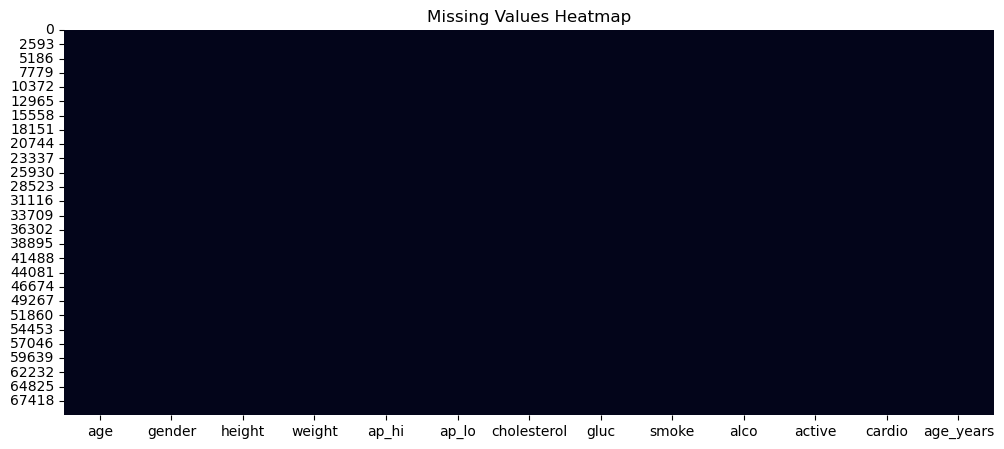

In [15]:
plt.figure(figsize=(12, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [16]:
# df = df.dropna()


# df["weight"] = df["weight"].fillna(df["weight"].mean())
# df["weight"] = df["weight"].fillna(df["weight"].median())
# df["cholesterol"] = df["cholesterol"].fillna(
    # df["cholesterol"].mode()[0]
# )

In [17]:
df.duplicated().sum()

np.int64(24)

In [18]:
df[df.duplicated()]

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
10562,20495,1,165,70.0,120,80,1,1,0,0,1,0,56
21784,16793,1,165,68.0,120,80,1,1,0,0,1,0,45
38505,18988,1,164,65.0,120,80,1,1,0,0,1,0,51
40365,14552,1,158,64.0,120,80,1,1,0,0,1,0,39
42450,18353,1,169,67.0,120,80,1,1,0,0,1,0,50
44653,16937,2,170,70.0,120,80,1,1,0,0,0,0,46
45125,21280,1,165,65.0,120,80,1,1,0,0,1,0,58
45748,22077,1,175,69.0,120,80,1,1,0,0,1,1,60
45810,21230,1,164,62.0,120,80,1,1,0,0,1,0,58
48917,21945,1,165,60.0,120,80,1,1,0,0,1,0,60


In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (69976, 13)
After: (69976, 13)


In [22]:
df.dtypes

age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
age_years        int64
dtype: object

In [23]:
for column in df.columns:
    print(column, ":", df[column].unique())

age : [18393 20228 18857 ... 14925 17727 17926]
gender : [2 1]
height : [168 156 165 169 151 157 178 158 164 173 181 172 170 154 162 163 153 159
 166 155 160 175 171 152 187 148 179 180 188 185 167 183 174 176 161 184
 177 182  76 149 142 150 144 147 186 146 141 195 140 198 145 143 196 138
 194 190 134 136 100 120 189 137 192 122 250 191 117  70  97 119 130 110
 193  75 132  71 135  67 125 139 133  74  98 112 207  68  55  81  80  64
  91  60 109  72 197  65 128 105 108 200 104 111 113  96 131  59  66  99
  57]
weight : [ 62.    85.    64.    82.    56.    67.    93.    95.    71.    68.
  80.    60.    78.   112.    75.    52.    83.    69.    90.    45.
  65.    59.    66.    74.   105.    73.    55.    70.    72.    63.
  50.   107.    84.    77.    79.    76.    58.   115.    97.    53.
  57.    49.   110.    94.    92.    87.   103.    88.    99.   100.
  61.    48.    54.    51.    47.    91.   104.    81.    98.   108.
  89.   101.    86.    65.5  142.    96.    44.    41.   169.

In [24]:
for column in df.columns:
    print("\n", column)
    print(df[column].value_counts().sort_index())


 age
age
10798    1
10859    1
10878    1
10964    1
14275    1
        ..
23687    1
23690    1
23692    1
23701    1
23713    1
Name: count, Length: 8076, dtype: int64

 gender
gender
1    45509
2    24467
Name: count, dtype: int64

 height
height
55      1
57      1
59      1
60      1
64      1
       ..
197     4
198    14
200     1
207     1
250     1
Name: count, Length: 109, dtype: int64

 weight
weight
10.0     1
11.0     1
21.0     1
22.0     1
23.0     1
        ..
178.0    3
180.0    4
181.0    1
183.0    1
200.0    2
Name: count, Length: 287, dtype: int64

 ap_hi
ap_hi
-150      1
-140      1
-120      2
-115      1
-100      2
         ..
 11020    1
 11500    1
 13010    2
 14020    4
 16020    1
Name: count, Length: 153, dtype: int64

 ap_lo
ap_lo
-70        1
 0        21
 1         1
 6         2
 7         2
          ..
 9011      2
 9100      1
 9800      1
 10000     3
 11000     1
Name: count, Length: 157, dtype: int64

 cholesterol
cholesterol
1    52361
2     

In [25]:
print("gender:", df["gender"].unique())
print("cholesterol:", df["cholesterol"].unique())
print("gluc:", df["gluc"].unique())
print("smoke:", df["smoke"].unique())
print("alco:", df["alco"].unique())
print("active:", df["active"].unique())
print("cardio:", df["cardio"].unique())

gender: [2 1]
cholesterol: [1 3 2]
gluc: [1 2 3]
smoke: [0 1]
alco: [0 1]
active: [1 0]
cardio: [0 1]


In [26]:
df[[
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]].min()

age       10798.0
height       55.0
weight       10.0
ap_hi      -150.0
ap_lo       -70.0
dtype: float64

In [27]:
df[[
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]].max()

age       23713.0
height      250.0
weight      200.0
ap_hi     16020.0
ap_lo     11000.0
dtype: float64

In [28]:
for column in ["age", "height", "weight", "ap_hi", "ap_lo"]:
    print(column, ":", (df[column] == 0).sum())

age : 0
height : 0
weight : 0
ap_hi : 0
ap_lo : 21


In [29]:
for column in ["age", "height", "weight", "ap_hi", "ap_lo"]:
    print(column, ":", (df[column] < 0).sum())

age : 0
height : 0
weight : 0
ap_hi : 7
ap_lo : 1


In [30]:
df["age_years"] = (df["age"] / 365.25).round(1)

In [31]:
df[["age", "age_years"]].head()

,age,age_years
0,18393,50.4
1,20228,55.4
2,18857,51.6
3,17623,48.2
4,17474,47.8


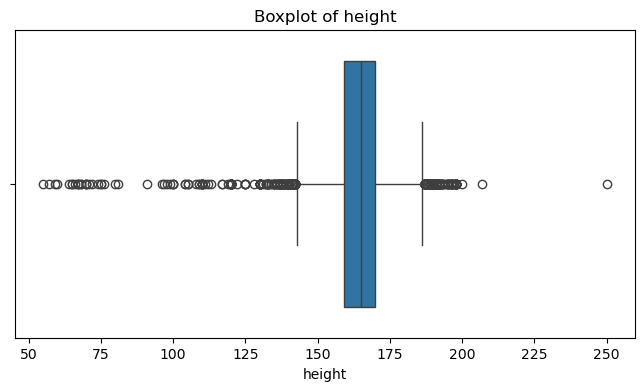

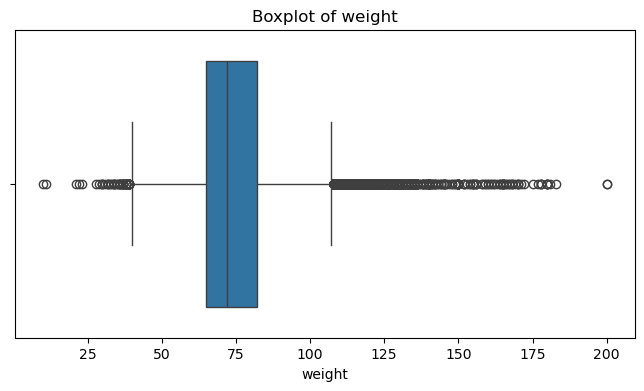

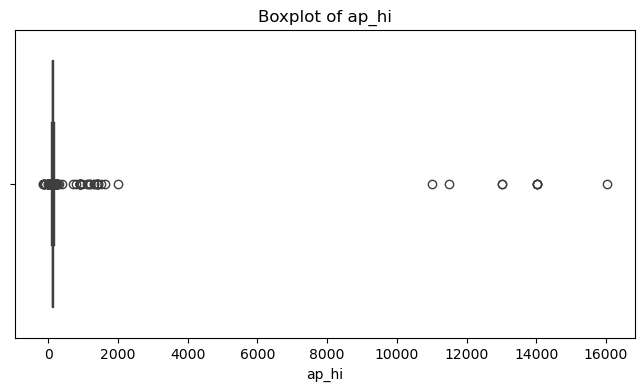

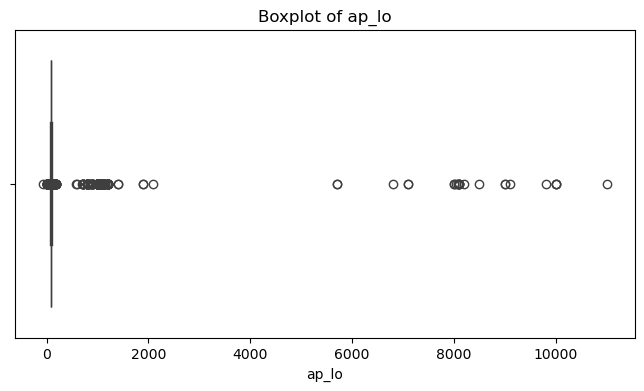

In [32]:
numeric_columns = [
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [33]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [34]:
for column in numeric_columns:

    outliers, lower, upper = detect_outliers_iqr(df, column)

    print("\nColumn:", column)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Outliers:", len(outliers))


Column: height
Lower Bound: 142.5
Upper Bound: 186.5
Outliers: 519

Column: weight
Lower Bound: 39.5
Upper Bound: 107.5
Outliers: 1819

Column: ap_hi
Lower Bound: 90.0
Upper Bound: 170.0
Outliers: 1435

Column: ap_lo
Lower Bound: 65.0
Upper Bound: 105.0
Outliers: 4632


In [35]:
df["height_m"] = df["height"] / 100

df["bmi"] = df["weight"] / (df["height_m"] ** 2)

In [36]:
df[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


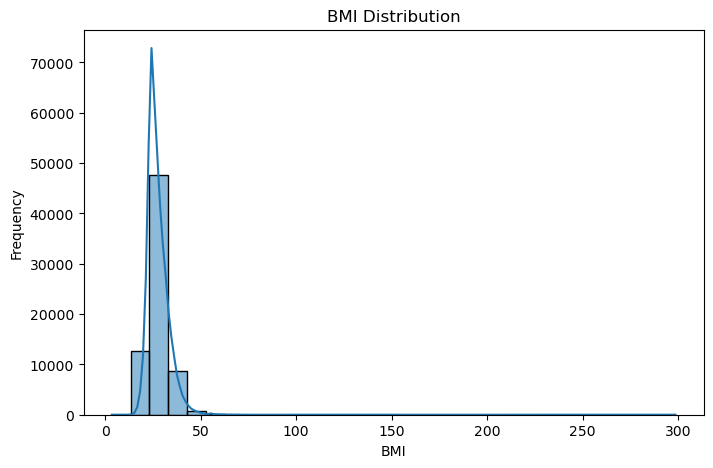

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(df["bmi"], bins=30, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

In [38]:
categorical_columns = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

for column in categorical_columns:

    print("\n", column)
    print(df[column].value_counts())


 gender
gender
1    45509
2    24467
Name: count, dtype: int64

 cholesterol
cholesterol
1    52361
2     9549
3     8066
Name: count, dtype: int64

 gluc
gluc
1    59455
3     5331
2     5190
Name: count, dtype: int64

 smoke
smoke
0    63807
1     6169
Name: count, dtype: int64

 alco
alco
0    66212
1     3764
Name: count, dtype: int64

 active
active
1    56241
0    13735
Name: count, dtype: int64

 cardio
cardio
0    35004
1    34972
Name: count, dtype: int64


In [39]:
y = df["cardio"]

In [40]:
X = df.drop(["cardio", "id"], axis=1)

KeyError: "['id'] not found in axis"

In [ ]:
scaler = StandardScaler()

numerical_features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

X[numerical_features] = scaler.fit_transform(
    X[numerical_features]
)

In [ ]:
df.to_csv(
    "../dataset/processed/cardio_processed.csv",
    index=False
)

In [ ]:
processed_df = pd.read_csv(
    "../dataset/processed/cardio_processed.csv"
)

processed_df.head()

In [41]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_cleaned.copy()

numerical_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]

scaler = StandardScaler()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

df_scaled.to_csv("../dataset/processed/cardio_scaled.csv", index=False)

print("✅ Scaled dataset successfully saved to: dataset/processed/cardio_scaled.csv")
print("Scaled Data Shape:", df_scaled.shape)
df_scaled.head()


✅ Scaled dataset successfully saved to: dataset/processed/cardio_scaled.csv
Scaled Data Shape: (69976, 15)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,height_m,bmi
0,18393,2,0.443402,-0.847984,-0.122182,-0.088255,1,1,0,0,1,0,-0.429751,1.68,-0.917652
1,20228,1,-1.018023,0.749559,0.072577,-0.035205,3,1,0,0,1,1,0.310397,1.56,1.209762
2,18857,1,0.078046,-0.709067,0.007658,-0.141304,3,1,0,0,0,1,-0.252115,1.65,-0.664756
3,17623,2,0.565188,0.541184,0.137497,0.017844,1,1,0,0,1,1,-0.755415,1.69,0.189238
4,17474,1,-1.018023,-1.264734,-0.187101,-0.194353,1,1,0,0,0,0,-0.814627,1.56,-0.746275


In [42]:
df_scaled.shape

(69976, 15)